In [1]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="your_username",
    password="your_password",
    database="superstore_analysis"
)

print("Connected Successfully")

Connected Successfully


In [11]:
import os

os.makedirs("charts", exist_ok=True)

Monthly Sales Trend

C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\2795162089.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


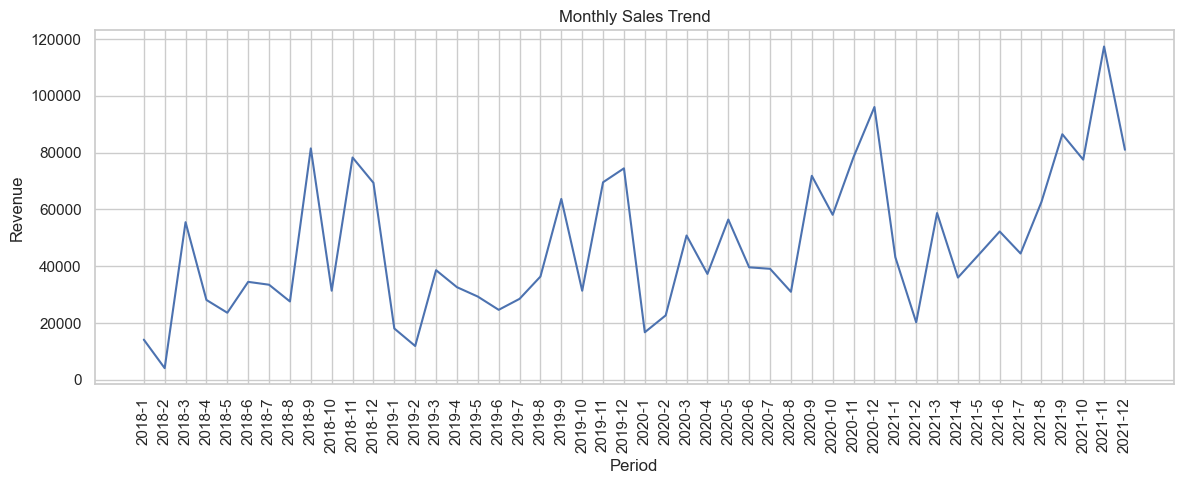

In [12]:
query = """
SELECT
YEAR(STR_TO_DATE(`Order Date`, '%m/%d/%Y')) AS Year,
MONTH(STR_TO_DATE(`Order Date`, '%m/%d/%Y')) AS Month,
SUM(Sales) AS Revenue
FROM superstore
GROUP BY Year, Month
ORDER BY Year, Month;
"""

df = pd.read_sql(query, conn)

df["Period"] = df["Year"].astype(str) + "-" + df["Month"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="Period", y="Revenue")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Sales by Category

C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\192974200.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


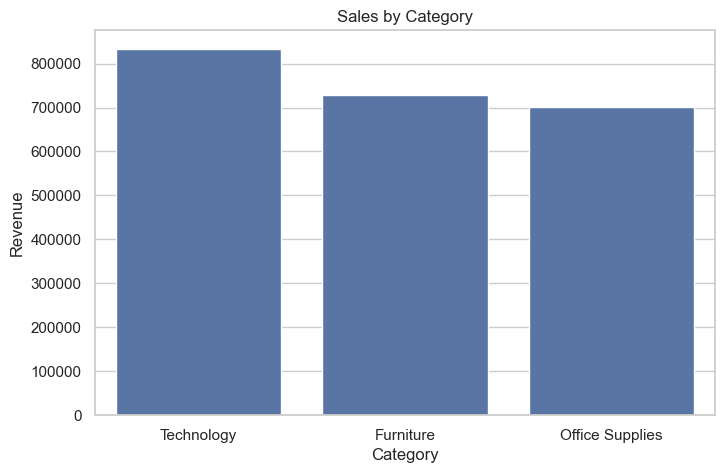

In [13]:
query = """
SELECT Category,
       SUM(Sales) AS Revenue
FROM superstore
GROUP BY Category
ORDER BY Revenue DESC;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Category", y="Revenue")
plt.title("Sales by Category")
plt.savefig("charts/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Sales by Region

C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\763303903.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


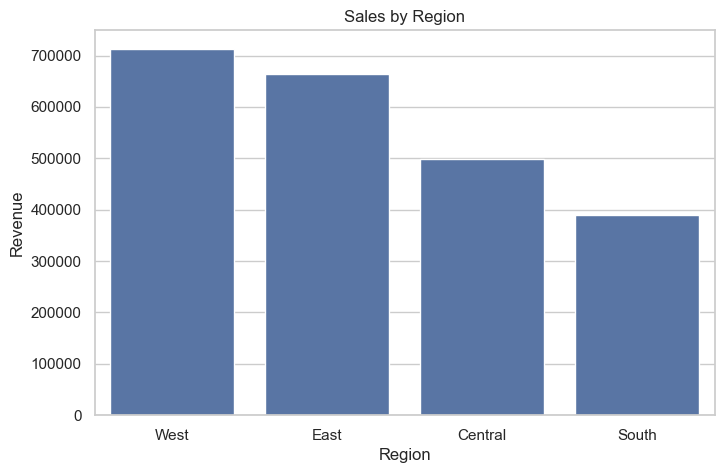

In [14]:
query = """
SELECT Region,
       SUM(Sales) AS Revenue
FROM superstore
GROUP BY Region
ORDER BY Revenue DESC;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Region", y="Revenue")
plt.title("Sales by Region")
plt.savefig("charts/region_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Profit by Category

C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\3119215788.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


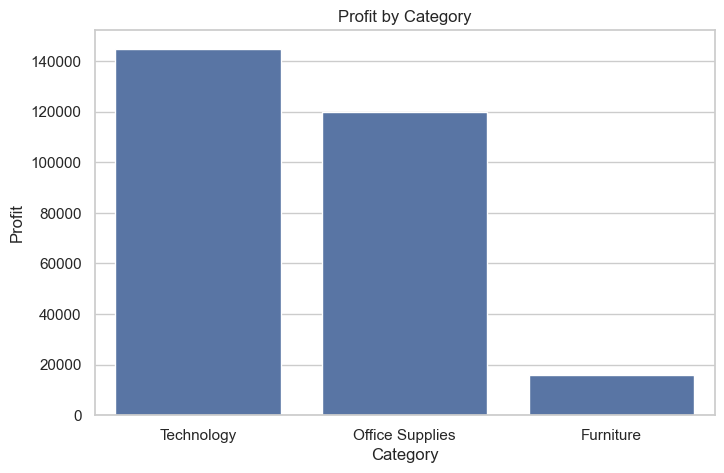

In [15]:
query = """
SELECT Category,
       SUM(Profit) AS Profit
FROM superstore
GROUP BY Category
ORDER BY Profit DESC;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Category", y="Profit")
plt.title("Profit by Category")
plt.savefig("charts/profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()